# Ahmet Burak Şişci

#### ML outlier: hıcanın dosyası. göndereceğini söyledi 

# outlier (Aykırı değer) nedir?
* ölçğm cihazı bozuk olabilir
* yanlışlıkla yanlış değer girilebilir. (insan faktörü)
* nadir durumlar. sınav ortalaması 20 ama bi kişi 100 almıi gibi gibi
* sensörlerin hatalı ölçümleri
* **ortalama ve standart sapmayı etkileriler .**

### univariate outliers

**Tek Değişkenli Aykırı Değerler (Univariate Outliers), bir veri setindeki tek bir değişkene ait olup, o değişkenin diğer gözlemlerinden anormal derecede farklı olan veri noktalarıdır.**
* Örnek: Bir sınıfta öğrencilerin yaşları 18–22 arasındayken, bir öğrencinin yaşı 45 ise bu, yaş değişkeni açısından bir univariate outlier’dır.

### mutivariate outliers

**Çok Değişkenli Aykırı Değerler (Multivariate Outliers), bir veri setindeki birden fazla değişkenin birleşimi açısından, diğer gözlemlerden anormal derecede farklı olan veri noktalarıdır.**
* Bu tür aykırı değerler, tek tek değişkenler incelendiğinde normal görünebilir, ancak değişkenler arasındaki ilişki bağlamında sıra dışıdır.
* Örnek: Bir kişinin boyu (180 cm) ve kilosu (80 kg) tek başına normal değerlerdir. Ancak, aynı kişinin IQ'su (150) ve ayakkabı numarası (35) gibi birbiriyle ilişkisiz iki değişkenin birleşimi, veri setindeki diğer kişilerin IQ-ayakkabı numarası kombinasyonlarından çok farklıysa, bu bir çok değişkenli aykırı değer olabilir.

### local outlier factor (yoğunluk komşuluk temkinli aykırı değer)
**Yerel Aykırı Değerler (Local Outliers), bir veri noktasının tüm veri setine göre değil, kendi yakın komşularına göre aykırı olması durumudur.**
Geleneksel aykırı değer tespit yöntemleri (global outliers), tüm veri setinin ortalamasına veya dağılımına göre bir noktanın ne kadar uçta olduğunu ölçerken, yerel aykırı değerler, noktanın kendi çevresindeki yoğunluğa göre ne kadar izole olduğunu değerlendirir.
Örnek: Bir şehirdeki ev fiyatlarını düşünün. Şehrin genelinde fiyatlar yüksek olsa bile, bir mahalledeki (yerel bölge) evlerin fiyatları çok daha düşükse, bu mahalledeki düşük fiyatlı bir ev, tüm şehre göre normal sayılabilirken, kendi mahallesindeki diğer evlere göre bir aykırı değer (local outlier) olabilir.

* lof yöntemi (local outlier factor): Yerel Aykırılık Faktörü (Local Outlier Factor - LOF), bir veri noktasının yerel aykırılık derecesini ölçmek için kullanılan yoğunluk tabanlı bir algoritmadır.

**hocanın dökümannın da bu kısım için çok güzel bir karşılştırma tablo var. buna mutlaka bakın**

In [2]:
import pandas as pd
import numpy as np

np.random.seed(0)  # 'radom' değil, 'random' olacak
# normal + biraz aşırı uç değer 
values = np.concatenate([
    np.random.normal(50, 10, 200),  # normal dağılım 
    np.random.normal(100, 5, 5),    # yüksek uç değerler 
    np.random.normal(10, 5, 5)      # düşük uç değerler
])  

df = pd.DataFrame({"value": values})
df.to_csv("outlier_demo.csv", index=False)

Bu kod, aykırı değer (outlier) içeren örnek bir veri seti oluşturur:

1. **200 normal değer**: Ortalaması 50, standart sapması 10 olan normal dağılımdan üretilir.  
2. **5 yüksek uç değer**: Ortalaması 100 civarında (normalden çok daha büyük).  
3. **5 düşük uç değer**: Ortalaması 10 civarında (normalden çok daha küçük).  

Tüm bu değerler birleştirilip `value` adlı tek bir sütundan oluşan bir DataFrame’e konur ve `outlier_demo.csv` dosyasına kaydedilir.  

Amacı: **Aykırı değer tespiti** gibi analizler için örnek veri sağlamaktır.

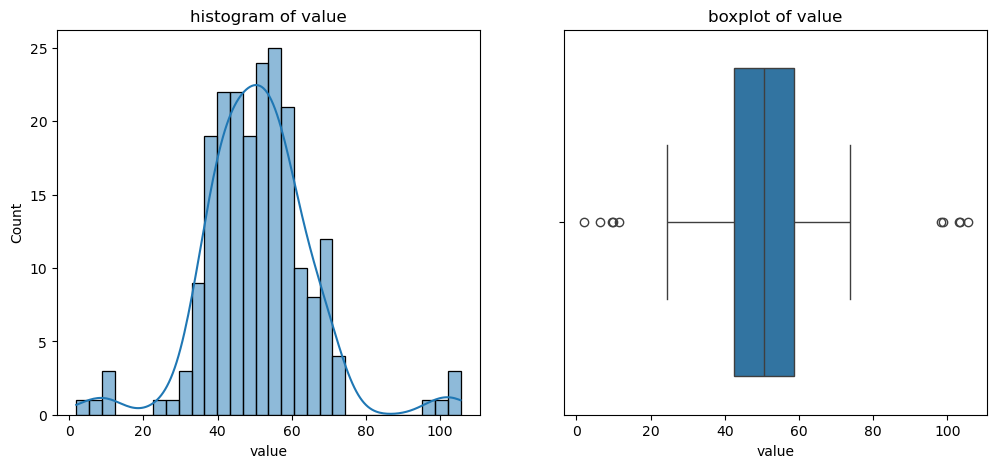

In [8]:
# örnek kod: hocanın dökümanından 

# 1. görselleştirme: + boxplot / histogram
# amaç: görsel olarak uç değerleri, dağılımımn kuyruklarını fark etmek. 

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv("outlier_demo.csv")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df["value"], bins=30, kde=True)
plt.title("histogram of value")

plt.subplot(1,2,2)
sns.boxplot(x=df["value"])
plt.title("boxplot of value")

plt.show()

In [9]:
# 2. Z-Score Yöntemi ile Aykırı Değer Tespiti

# Z-score > 3 veya < –3 → genelde aykırı olarak kabul edilir.

# Ne zaman uygundur? Veri yaklaşık normal dağılmışsa; aşırı uç değerler değil de daha “ölçek dışı” değer ararken.


from scipy.stats import zscore

df["z_score"] = zscore(df["value"])
outliers_z = df[np.abs(df["z_score"]) > 3]
print("Z-score ile belirlenen outlier’lar:", outliers_z)


Z-score ile belirlenen outlier’lar:           value   z_score
200   98.154091  3.294201
201   98.803104  3.339449
202  105.498298  3.806224
203  103.276319  3.651312
204  103.200658  3.646037
205    1.915220 -3.415370
207    6.309845 -3.108986


In [10]:
# 3. IQR / Tukey Metodu ile Aykırı Değer Tespiti

# IQR metodu, dağılım şekli ne olursa olsun (çarpık, simetrik) güçlü ve yaygın kullanılan bir yöntemdir. 

Q1 = df["value"].quantile(0.25)
Q3 = df["value"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["value"] < lower_bound) | (df["value"] > upper_bound)] 
# IQR ile outlier belirleme en çok tercih edilenlerdendir. her türlü dağılımda iş yar. ****


print("IQR ile belirlenen outlier’lar:", outliers_iqr)


IQR ile belirlenen outlier’lar:           value   z_score
200   98.154091  3.294201
201   98.803104  3.339449
202  105.498298  3.806224
203  103.276319  3.651312
204  103.200658  3.646037
205    1.915220 -3.415370
206    9.878369 -2.860196
207    6.309845 -3.108986
208   11.399623 -2.754137
209    9.509248 -2.885930


           x1        x2  outlier
200  4.202786  4.700312     True
201  5.002622  5.023490     True
202  4.774967  5.311425     True
203  4.466190  4.928810     True
204  5.060148  5.257219     True


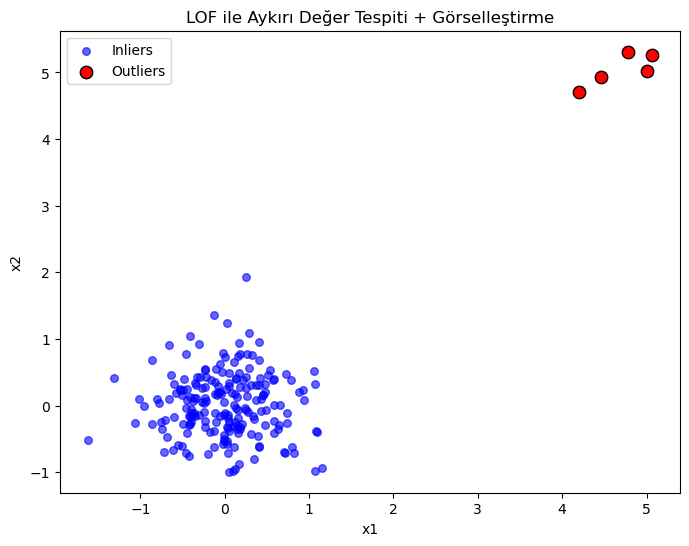

In [12]:
from sklearn.neighbors import LocalOutlierFactor  
import numpy as np  
import pandas as pd 

# --- Simüle veri oluşturma ---
rng = np.random.RandomState(42)  
# RandomState ile reproducible (tekrarlanabilir) rastgele sayı üreticisi oluşturduk — aynı rastgele sayılar her çalışmada üretilir.

# “Normal / inlier” veri: 200 örnek, 2 değişkenli, ortalama 0, standart sapma 0.5
X_inliers = rng.normal(0, 0.5, size=(200, 2))

# “Aykırı / outlier” veri: 5 örnek, 2 değişkenli, ortalama 5, standart sapma 0.5 → bu noktalar diğerlerinden oldukça farklı
X_outliers = rng.normal(5, 0.5, size=(5, 2))

# Inlier ve outlier verilerini tek numpy dizisinde birleştiriyoruz
X = np.vstack([X_inliers, X_outliers])

# Numpy dizisini pandas DataFrame’e çeviriyoruz, kolon isimlerini “x1”, “x2” yapıyoruz
df2 = pd.DataFrame(X, columns=["x1", "x2"])

# --- LOF Modeli (Yerel Aykırı Değer Algılama) ---

# LOF nesnesini tanımlıyoruz. Parametreler:
#   n_neighbors=20 → Her nokta için 20 en yakın komşusuna bakar.
#   contamination=0.02 → Veri setindeki yaklaşık %2 kadar gözlemin aykırı olabileceğini varsayar. Buna göre eşik belirlenir. 
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02) # contamination kısmmımnı belirleymezsen otomatik olarakta belirletebilrisain. 

# fit_predict ile hem modele “uygula” hem de her gözlem için -1 (outlier) / 1 (inlier) etiketi üret
y_pred = lof.fit_predict(df2)

# DataFrame’e yeni bir kolon ekle: outlier — True ise outlier, False ise inlier
df2["outlier"] = (y_pred == -1)

# Aykırı olduklarını tespit ettiği gözlemleri yazdır
print(df2[df2["outlier"]])

# 3. Görselleştirme
plt.figure(figsize=(8,6))
# Inlier’lar
plt.scatter(
    df2.loc[~df2["outlier"], "x1"],
    df2.loc[~df2["outlier"], "x2"],
    c="blue",
    label="Inliers",
    s=30,
    alpha=0.6
)
# Outlier’lar
plt.scatter(
    df2.loc[df2["outlier"], "x1"],
    df2.loc[df2["outlier"], "x2"],
    c="red",
    label="Outliers",
    s=80,
    edgecolor="k"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("LOF ile Aykırı Değer Tespiti + Görselleştirme")
plt.legend()
plt.show()

In [ ]:
**n_neighbors ve contamination belirlerken dikkatli daranmlısın. çok önemli**

* elimde çok fazla veri varsa outlier ları sil at. buraada asıl sıkıntı uç değerleri ve aykırı değerleri tespit edebilmek.
* **uç değerkleri silersen model ezber yapar. sıkıntı olur**   (not: bugün çok yorgunum)

**Outlier’lara Ne Yapmalı? Temel Stratejiler**</br>

**Çıkarma (drop):** Temizleme, analiz kalitesini arttırır; ancak “gerçek ekstrem değerleri” yanlışlıkla silmemeye dikkat.</br>

**Dönüştürme (transform):** Log, sqrt gibi dönüşümlerle aşırı uçların etkisini azaltmak.</br>

**İşaretleme (flagging):** “Bu gözlem outlier” etiketi eklemek → modelde outlier bilgisini kullanılabilir yapmak ya da ayrı analiz.</br> (outlier olanalara 1 yaz, olmayanlara 0 yaz mesela)

**Robust metodlar kullanmak:** Medyan, IQR, robust scaler, ağaç tabanlı modeller vb.</br>

**aykırı değerler ortalama ve standart sapmayı etliker. bu kavramlarla ilgilnemyen modeller aykırı yöntemlerden etkilenmez**bu yüzden robust metotlar aykırı değerlerden etkilenmez. 
* regresyoni ağaç tabanlı ve istatistikls yöntemker ile aykırı değerelerin model performansına olan negatif etkisisi mininum olabilir.

### buradam sonra hoca **ml_miputation** adlı dökümana geçiş yaptı. 

# boş / eksik verilerin yönetimi ve doldurma 

**Eksik Veri Nedir & Neden Önemli?**</br>
* Eksik veri (missing / null / NaN): Bir gözlem (satır) ve özellik (sütun) için geçerli bir değer olmaması demektir. Bu “0” değerinden farklıdır.
* Eksik veri nedenleri: ölçüm hatası, veri girişi hatası, sensör arızası, kullanıcı cevapsızlığı (anket), kayıt hatası, veri kaybı, dataset birleşimi vb.
* Eksik verilerin etkileri: analiz döneminde ortalamalar, dağılımlar, korelasyonlar bozulabilir; bazı modeller NaN ile çalışamaz; veri kaybı olabilir. Bu yüzden missing data ile çalışırken dikkatli olmak gerekir.
* Eksik veri ile baş etme temelde 3 yol vardır:
  1. Satır / sütun silme (drop).
  2. Eksik değerleri doldurma (imputation).
  3. Eksikliği model / analiz metodunun göze alamayacağı durumlarda özel yöntemler (model-based, generative, maximum-likelihood, multiple imputation ...).


**Yaygın Eksik Veri Doldurma / Imputation Yöntemleri**</br>

| Yöntem/Strateji                                                                  | Ne zaman / nerede kullanılır / Avantaj / Dezavantaj                                                                                                                                                                                            |
| -------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Ortalama (Mean), Medyan, Mod**                                                 | Sayısal değişkenlerde; düşük oranda eksik varsa; veri dağılımı çok bozulmamışsa. Basit ve hızlıdır. Ancak dağılım bozuksa (çarpık, çok uç değer) ortalama yanıltıcı olabilir. Medyan/mod bu durumda daha güvenli olabilir.  |
| **Sabit Değer / Sabit Kod (Constant Imputation)**                                | Eksik veriler için anlamlı sabit bir değer varsa ya da “bilinmiyor” gibi bir değer mantıklı ise (örneğin yaş bilinmiyorsa –1 atamak gibi). Kolay ama dikkatli kullanılmalı.                                         |
| **Forward / Backward Fill (ffill / bfill)**                                      | Zaman serisi ya da sıralı veri varsa; önceki ya da sonraki gözleme göre doldurmak mantıklı ise. Ancak sıranın mantıklı olması gerekir.                                                                                       |
| **KNN Imputation (En yakın komşulara göre doldurma)**                            | Eksik değer başka değişkenlerle ilişkiliyse ve benzer gözlemler varsa; özellikle çok değişkenli veri setlerinde. Eksik değer bağımsız değilse mantıklı.                                                                           |
| **Regression / Model-based Imputation**                                          | Eksik değişkenin diğer değişkenlerle güçlü ilişkisi varsa; regresyon, karar ağacı vb modellerle tahmin edilebilir. Ancak model varsayımlarına dikkat.                                                                    |
| **Çoklu İmputation (Multiple Imputation), Iterative Imputer, EM gibi yöntemler** | Eksik veri oranı yüksekse, missing değerlerin rastgele dağılmadığı biliniyorsa; sadece bir doldurma yerine çoklu doldurmalar + varyans dahil edilmek isteniyorsa.                                  


---
* çok boş veir avarsa o satırı sil at.
* imputation(eksik değerleri doldurma) **(eksiklik yeni bir model ile doldurlabilir.)**

* sözel alan: mod , sayısal alan: medyan ile dolar çoğunlukla. ortalama çok etkilendiği için genelde kullanılmaz.
* bazen sabit değer ilei doldurulur (girilmedi veya 0 gibi)
* bfil, ffil :önceki ve sonraki veriler ile doldurulabilir. (finansal işler genelde bu şekilde doldurulur. (sürkli veri))
* knn imputation -> komuşuluklara bakarak eksikleri doldurur. (kuvvetli vbir yöntem )
* regresyon modeli kurulabilri.
* çoklu imputitation **çıok öullanıcaz** : eksik veri çoksa ve değerler rastgele dağılmıyorsa bu kullanılabilir / birdewn fazla yötem kullanılır bu durumda. 

In [14]:
# Örnek veri seti (simülasyon + boş değer oluşturma)

import pandas as pd
import numpy as np

np.random.seed(42)

# 100 satır, 4 sütun
df = pd.DataFrame({
    'age': np.random.randint(18, 70, size=100), # ratgele 18-70 arası kişiler oluşuturyor.
    'income': np.random.normal(50000, 15000, size=100),
    'education_years': np.random.randint(8, 20, size=100), # eitim yılı rastgele olulturuldu. 
    'city': np.random.choice(['A','B','C'], size=100) 
})

# Rasgele %10 eksik değer atama
for col in ['income', 'education_years', 'city']:
    df.loc[df.sample(frac=0.1).index, col] = np.nan # frac: %10 luk bir eksik değer atama işlemini gerçeklelşştirir. 

df.head()
df.isnull().mean() * 100  # her bir sütunda eksik oranı %


age                 0.0
income             10.0
education_years    10.0
city               10.0
dtype: float64

In [16]:
# Temel Imputation: Mean / Median / Mode

# SimpleImputer kullanarak eksik sayısal değerleri sütunun medyanıyla, 
# kategorik verileri ise en sık görülen (mod) ile dolduruyor.

from sklearn.impute import SimpleImputer

# Sayısal değişkenler için medyan, kategorik için mod
num_cols = ['age', 'income', 'education_years']
cat_cols = ['city']

imp_num = SimpleImputer(strategy='median')
df[num_cols] = imp_num.fit_transform(df[num_cols])

imp_cat = SimpleImputer(strategy='most_frequent') # kategorik için en çok most_frequent kullanılır. (en çok tekrar eden değer.)
df[cat_cols] = imp_cat.fit_transform(df[cat_cols])

df.isnull().sum()


age                0
income             0
education_years    0
city               0
dtype: int64

**basit bir atama yapacaksan SimpleImputater kullan(from sklearn.impute import SimpleImputer)**
* kategorik için en çok most_frequent kullanılır. (en çok tekrar eden değer.)

In [17]:
# KNN Imputation

# KNN tabanlı doldurma: eksik değer olan satırın, diğer satırlara göre benzer (komşu) 
# satırlarının ortalaması / medyanı ile doldurma. Özellikle çok değişkenli ilişkilere göre daha mantıklı.

from sklearn.impute import KNNImputer # komşuluk

df2 = df.copy()

imputer = KNNImputer(n_neighbors=5) #komşuluk(n_neighbors) değerini biz veriye göre veririz. bu doğrukluk için önemli 
df2[num_cols] = imputer.fit_transform(df2[num_cols])

df2.head()

,age,income,education_years,city
0,56.0,21864.848417,17.0,C
1,69.0,29498.267917,10.0,B
2,46.0,59544.576625,14.0,A
3,32.0,36399.189971,19.0,B
4,60.0,57140.638811,17.0,C


In [18]:
# Iterative Imputer / Model-Based Imputation (Regresyon / tahmin)

# IterativeImputer her bir eksik değeri, diğer değişkenleri kullanarak ardışık 
#tahminlerle doldurur 
# — regresyon, bayesçi yöntem vs kullanabilir. Bu, imputation sonrası değişkenler
# arası ilişkiyi korumaya çalışan güçlü bir yöntemdir. 

from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer

df3 = df.copy()

imp_iter = IterativeImputer(random_state=42) # random_state vermek zorunda değilsin ama ver. hep farklı deeğerler üretme. 
df3[num_cols] = imp_iter.fit_transform(df3[num_cols])

df3.head()


,age,income,education_years,city
0,56.0,21864.848417,17.0,C
1,69.0,29498.267917,10.0,B
2,46.0,59544.576625,14.0,A
3,32.0,36399.189971,19.0,B
4,60.0,57140.638811,17.0,C
